In [1]:
# 1. Imports and project settings
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_absolute_percentage_error,
    root_mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
FAST_MODE = True  # Change to False before final evaluation.
TRAINING_SAMPLE_SIZE = 100_000  # Used only when FAST_MODE is True.

PROJECT_ROOT = Path.cwd().resolve()
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
MODEL_DIR = ARTIFACT_DIR / "models"
PLOT_DIR = ARTIFACT_DIR / "plots"
REPORT_DIR = ARTIFACT_DIR / "reports"
for folder in [MODEL_DIR, PLOT_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

dataset_candidates = [
    PROJECT_ROOT / "data" / "raw" / "emi_prediction_dataset.csv",
    Path.home() / "Downloads" / "emi_prediction_dataset.csv",
]
RAW_DATA_PATH = next((path for path in dataset_candidates if path.exists()), None)
if RAW_DATA_PATH is None:
    raise FileNotFoundError(
        "Dataset not found. Place emi_prediction_dataset.csv in data/raw/."
    )

print(f"Using dataset: {RAW_DATA_PATH}")
print(f"Fast mode: {FAST_MODE}")


c:\Users\jenis\OneDrive\Documents\ChatGPT\EMIPredict AI - Intelligent Financial Risk\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using dataset: C:\Users\jenis\Downloads\emi_prediction_dataset.csv
Fast mode: True


## 2. Load the real dataset

We read the actual CSV before making any assumptions about its columns or values.


In [2]:
df_raw = pd.read_csv(RAW_DATA_PATH, low_memory=False)

print(f"Rows and columns: {df_raw.shape}")
print(f"Memory usage: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
display(df_raw.head())
display(pd.DataFrame({"column": df_raw.columns, "dtype": df_raw.dtypes.astype(str)}))


Rows and columns: (404800, 27)
Memory usage: 344.83 MB


,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


,column,dtype
age,age,object
gender,gender,object
marital_status,marital_status,object
education,education,object
monthly_salary,monthly_salary,object
employment_type,employment_type,object
years_of_employment,years_of_employment,float64
company_type,company_type,object
house_type,house_type,object
monthly_rent,monthly_rent,float64


## 3. Data-quality report

We count missing values and duplicates before changing anything. The report is saved so it can be shown during evaluation.


In [3]:
quality_report = pd.DataFrame(
    {
        "dtype": df_raw.dtypes.astype(str),
        "missing_count": df_raw.isna().sum(),
        "missing_percent": (df_raw.isna().mean() * 100).round(2),
        "unique_values": df_raw.nunique(dropna=False),
    }
).sort_values("missing_count", ascending=False)

duplicate_rows = int(df_raw.duplicated().sum())
print(f"Duplicate rows: {duplicate_rows:,}")
display(quality_report)
quality_report.to_csv(REPORT_DIR / "data_quality_report.csv")


Duplicate rows: 0


,dtype,missing_count,missing_percent,unique_values
monthly_rent,float64,2426,0.60,4397
bank_balance,object,2426,0.60,12262
credit_score,float64,2420,0.60,428
education,object,2404,0.59,5
emergency_fund,float64,2351,0.58,5487
marital_status,object,0,0.00,2
monthly_salary,object,0,0.00,13662
years_of_employment,float64,0,0.00,356
gender,object,0,0.00,8
employment_type,object,0,0.00,3


## 4. Cleaning functions

The real CSV contains malformed numeric text such as `18000.0.0`, mixed gender labels, and missing values. We repair values carefully:

- Numeric conversion changes invalid text to missing values instead of guessing.
- Out-of-range age and credit score values become missing values.
- The machine-learning pipeline later fills missing numeric values with the training-set median and missing categories with the most frequent training category.
- No duplicate rows are removed automatically because this dataset has no exact duplicates.


In [4]:
NUMERIC_COLUMNS = [
    "age", "monthly_salary", "years_of_employment", "monthly_rent",
    "family_size", "dependents", "school_fees", "college_fees",
    "travel_expenses", "groceries_utilities", "other_monthly_expenses",
    "current_emi_amount", "credit_score", "bank_balance", "emergency_fund",
    "requested_amount", "requested_tenure", "max_monthly_emi",
]
CATEGORICAL_COLUMNS = [
    "gender", "marital_status", "education", "employment_type",
    "company_type", "house_type", "existing_loans", "emi_scenario",
    "emi_eligibility",
]

def normalise_numeric(series: pd.Series) -> pd.Series:
    # Turn normal numbers and malformed values like 18000.0.0 into numbers.
    text = series.astype("string").str.strip()
    text = text.str.replace(r"^(-?\d+(?:\.\d+)?)\.0$", r"\1", regex=True)
    return pd.to_numeric(text, errors="coerce")


def clean_data(frame: pd.DataFrame) -> pd.DataFrame:
    # Return a cleaned copy; the original dataframe is never changed.
    result = frame.copy()

    for column in NUMERIC_COLUMNS:
        result[column] = normalise_numeric(result[column])

    for column in CATEGORICAL_COLUMNS:
        # Keep standard Python objects and np.nan so SimpleImputer can process them.
        result[column] = result[column].astype(object)
        result[column] = result[column].map(
            lambda value: value.strip() if isinstance(value, str) else value
        )
        result[column] = result[column].where(result[column].notna(), np.nan)

    gender_map = {
        "M": "Male", "MALE": "Male", "male": "Male", "Male": "Male",
        "F": "Female", "FEMALE": "Female", "female": "Female", "Female": "Female",
    }
    result["gender"] = result["gender"].replace(gender_map)

    result.loc[~result["age"].between(18, 100), "age"] = np.nan
    result.loc[~result["credit_score"].between(300, 850), "credit_score"] = np.nan
    result.loc[result["monthly_salary"] <= 0, "monthly_salary"] = np.nan
    result.loc[result["requested_amount"] <= 0, "requested_amount"] = np.nan
    result.loc[result["requested_tenure"] <= 0, "requested_tenure"] = np.nan
    result.loc[result["dependents"] > result["family_size"], "dependents"] = np.nan
    return result


df_clean = clean_data(df_raw)
cleaned_missing = pd.DataFrame(
    {
        "before_cleaning": df_raw.isna().sum(),
        "after_cleaning": df_clean.isna().sum(),
    }
)
display(cleaned_missing[cleaned_missing.sum(axis=1) > 0])
print("Gender values after normalization:")
display(df_clean["gender"].value_counts(dropna=False))


,before_cleaning,after_cleaning
education,2404,2404
monthly_salary,0,3
monthly_rent,2426,2426
credit_score,2420,7196
bank_balance,2426,2447
emergency_fund,2351,2351


Gender values after normalization:


gender
Male      242950
Female    161850
Name: count, dtype: int64

## 5. Financial feature engineering

These features use only information available before a lending decision. The requested-payment proxy is **not** a bank EMI because the dataset has no interest-rate column.


In [5]:
def safe_divide(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    # Avoid division by zero and keep undefined values missing.
    return numerator / denominator.mask(denominator == 0)


def add_financial_features(frame: pd.DataFrame) -> pd.DataFrame:
    # Create transparent financial ratios for the models.
    result = frame.copy()
    expense_columns = [
        "monthly_rent", "school_fees", "college_fees", "travel_expenses",
        "groceries_utilities", "other_monthly_expenses",
    ]
    result["total_monthly_expenses"] = result[expense_columns].sum(axis=1)
    result["annual_income"] = result["monthly_salary"] * 12
    result["expense_to_income_ratio"] = safe_divide(
        result["total_monthly_expenses"], result["monthly_salary"]
    )
    result["existing_emi_burden"] = safe_divide(
        result["current_emi_amount"], result["monthly_salary"]
    )
    result["disposable_income"] = (
        result["monthly_salary"] - result["total_monthly_expenses"] - result["current_emi_amount"]
    )
    result["loan_to_income_ratio"] = safe_divide(result["requested_amount"], result["annual_income"])
    result["emergency_fund_coverage"] = safe_divide(
        result["emergency_fund"], result["total_monthly_expenses"]
    )
    result["balance_to_income_ratio"] = safe_divide(
        result["bank_balance"], result["monthly_salary"]
    )
    result["dependent_burden"] = safe_divide(result["dependents"], result["family_size"])
    result["requested_payment_proxy"] = safe_divide(
        result["requested_amount"], result["requested_tenure"]
    )
    result["financial_cushion"] = (
        result["disposable_income"] - result["requested_payment_proxy"]
    )
    return result


df_features = add_financial_features(df_clean)
TARGET_CLASSIFICATION = "emi_eligibility"
TARGET_REGRESSION = "max_monthly_emi"
feature_columns = [
    column for column in df_features.columns
    if column not in [TARGET_CLASSIFICATION, TARGET_REGRESSION]
]

print(f"Number of model input features after engineering: {len(feature_columns)}")
display(df_features[["total_monthly_expenses", "disposable_income", "financial_cushion"]].head())


Number of model input features after engineering: 36


,total_monthly_expenses,disposable_income,financial_cushion
0,59900,-1000.0,-57666.666667
1,15400,2000.0,-4736.842105
2,35600,50500.0,31375.0
3,37400,29400.0,25737.349398
4,58600,-1300.0,-37300.0


## 6. Exploratory data analysis

Each chart answers a simple business question: What is the eligibility distribution? How do scenarios differ? Is maximum EMI related to salary?


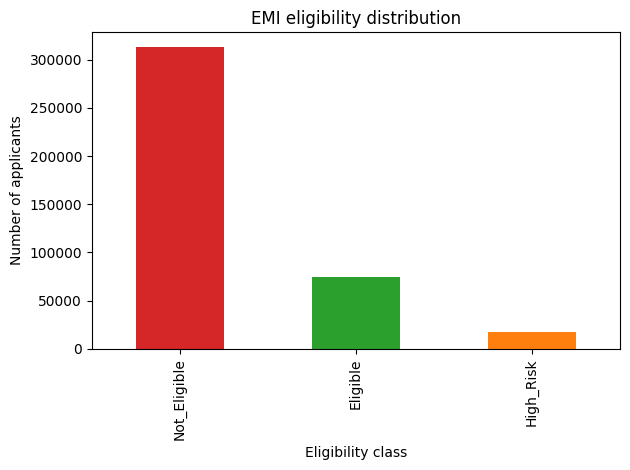

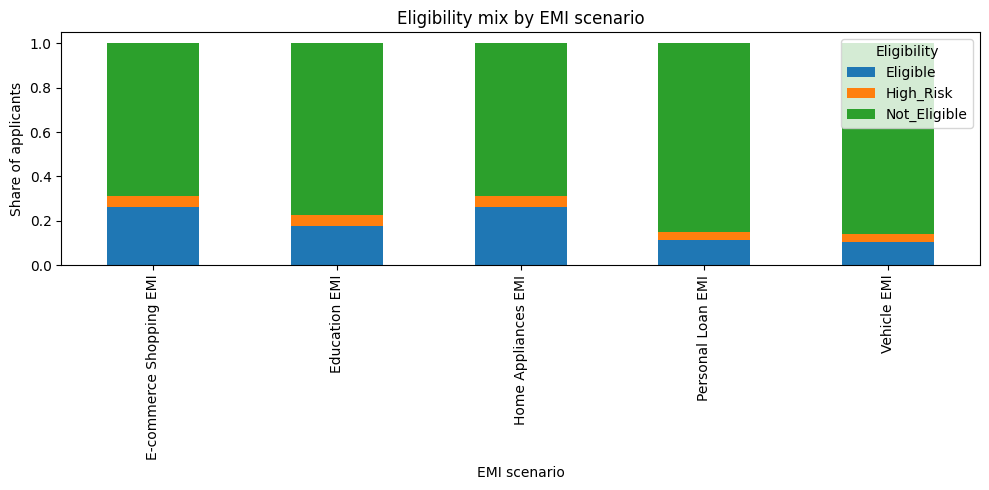

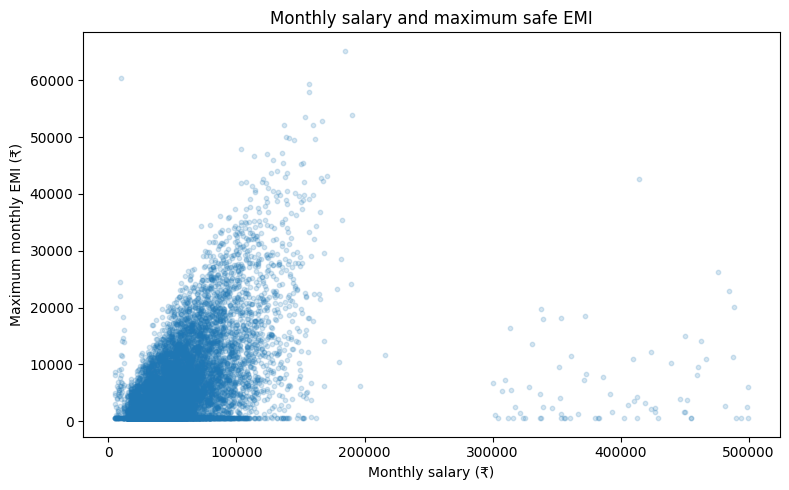

In [6]:
# Eligibility class distribution
class_counts = df_features[TARGET_CLASSIFICATION].value_counts()
ax = class_counts.plot(kind="bar", color=["#d62728", "#2ca02c", "#ff7f0e"])
ax.set_title("EMI eligibility distribution")
ax.set_xlabel("Eligibility class")
ax.set_ylabel("Number of applicants")
plt.tight_layout()
plt.savefig(PLOT_DIR / "eligibility_distribution.png", dpi=150)
plt.show()

# Eligibility by EMI scenario
scenario_table = pd.crosstab(
    df_features["emi_scenario"], df_features[TARGET_CLASSIFICATION], normalize="index"
)
scenario_table.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("Eligibility mix by EMI scenario")
plt.ylabel("Share of applicants")
plt.xlabel("EMI scenario")
plt.legend(title="Eligibility")
plt.tight_layout()
plt.savefig(PLOT_DIR / "eligibility_by_scenario.png", dpi=150)
plt.show()

# A sample is enough for a readable scatter plot.
plot_sample = df_features.sample(n=min(10_000, len(df_features)), random_state=RANDOM_STATE)
plt.figure(figsize=(8, 5))
plt.scatter(plot_sample["monthly_salary"], plot_sample[TARGET_REGRESSION], alpha=0.18, s=10)
plt.title("Monthly salary and maximum safe EMI")
plt.xlabel("Monthly salary (₹)")
plt.ylabel("Maximum monthly EMI (₹)")
plt.tight_layout()
plt.savefig(PLOT_DIR / "salary_vs_max_emi.png", dpi=150)
plt.show()


## 6. Exploratory data analysis

,count,mean,median,std
emi_eligibility,,,,
Eligible,73109,725.61,726.0,64.16
High_Risk,17198,715.94,715.0,64.88
Not_Eligible,307297,693.51,693.0,67.32


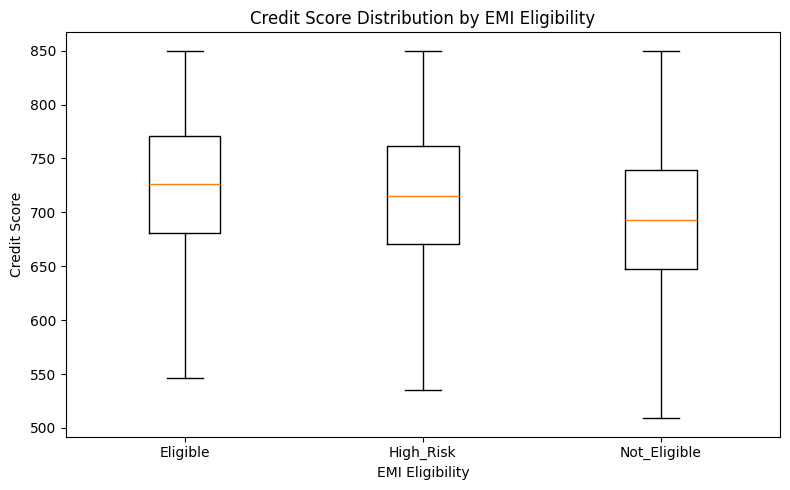

In [7]:
# Credit score analysis by EMI eligibility class

credit_score_summary = (
    df_features
    .groupby(TARGET_CLASSIFICATION)["credit_score"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

display(credit_score_summary)


# Prepare data for visualization
eligibility_order = [
    label
    for label in ["Eligible", "High_Risk", "Not_Eligible"]
    if label in df_features[TARGET_CLASSIFICATION].dropna().unique()
]

credit_score_groups = [
    df_features.loc[
        df_features[TARGET_CLASSIFICATION] == label,
        "credit_score"
    ].dropna()
    for label in eligibility_order
]


# Box plot
plt.figure(figsize=(8, 5))

plt.boxplot(
    credit_score_groups,
    tick_labels=eligibility_order,
    showfliers=False
)

plt.title("Credit Score Distribution by EMI Eligibility")
plt.xlabel("EMI Eligibility")
plt.ylabel("Credit Score")
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "credit_score_by_eligibility.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Business Insight — Credit Score vs EMI Eligibility

Credit score shows a clear relationship with EMI eligibility.

- Eligible customers have the highest average credit score at approximately **725.6**.
- High-risk customers have an average score of approximately **715.9**.
- Not-eligible customers have the lowest average score at approximately **693.5**.
- The distributions still overlap considerably, indicating that credit score alone is not sufficient to determine EMI eligibility.

Therefore, EMI risk assessment should combine creditworthiness with income, expenses, debt burden, requested loan characteristics, and other financial-capacity indicators.

,count,mean,median,std
emi_eligibility,,,,
Eligible,74444,0.589,0.533,0.531
High_Risk,17488,0.611,0.563,0.522
Not_Eligible,312865,0.84,0.759,0.58


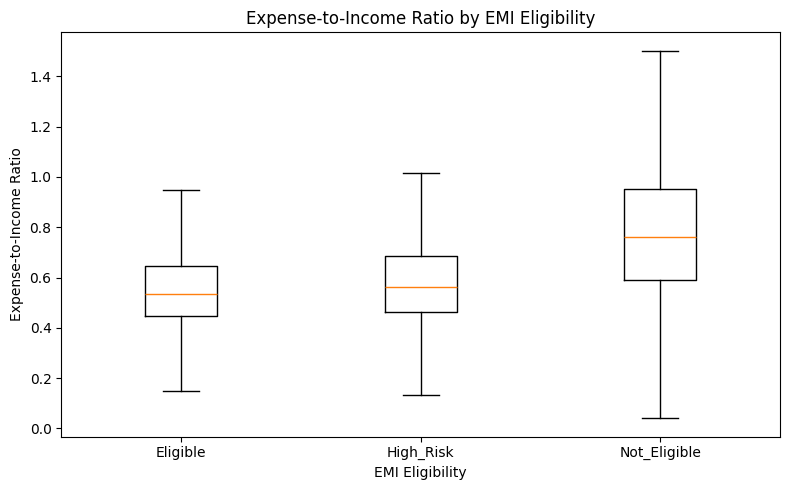

In [15]:
# Expense-to-income ratio analysis by EMI eligibility

expense_ratio_summary = (
    df_features
    .groupby(TARGET_CLASSIFICATION)["expense_to_income_ratio"]
    .agg(["count", "mean", "median", "std"])
    .round(3)
)

display(expense_ratio_summary)


# Prepare groups for visualization
eligibility_order = [
    label
    for label in ["Eligible", "High_Risk", "Not_Eligible"]
    if label in df_features[TARGET_CLASSIFICATION].dropna().unique()
]

expense_ratio_groups = [
    df_features.loc[
        df_features[TARGET_CLASSIFICATION] == label,
        "expense_to_income_ratio"
    ]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    for label in eligibility_order
]


# Box plot
plt.figure(figsize=(8, 5))

plt.boxplot(
    expense_ratio_groups,
    tick_labels=eligibility_order,
    showfliers=False
)

plt.title("Expense-to-Income Ratio by EMI Eligibility")
plt.xlabel("EMI Eligibility")
plt.ylabel("Expense-to-Income Ratio")
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "expense_ratio_by_eligibility.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Business Insight — Expense-to-Income Ratio

Expense burden shows a strong relationship with EMI eligibility.

- Eligible customers have an average expense-to-income ratio of approximately **58.9%**.
- High-risk customers average approximately **61.1%**.
- Not-eligible customers have a substantially higher average ratio of approximately **84.0%**.
- The median ratio also increases from **53.3% for Eligible** customers to **75.9% for Not_Eligible** customers.

This indicates that applicants whose monthly expenses consume a larger share of their income generally have lower capacity to take on additional EMI obligations.

However, the distributions overlap, so expense burden should be considered together with credit score, existing EMI obligations, savings, requested amount, and other financial indicators.

,count,mean,median,std
emi_eligibility,,,,
Eligible,74444,0.031,0.0,0.105
High_Risk,17488,0.043,0.0,0.123
Not_Eligible,312865,0.098,0.0,0.147


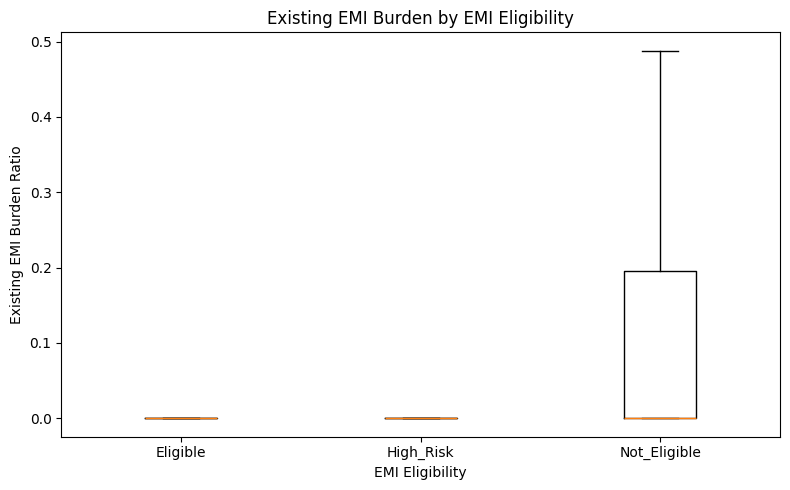

In [16]:
# Existing EMI burden analysis by EMI eligibility

emi_burden_summary = (
    df_features
    .groupby(TARGET_CLASSIFICATION)["existing_emi_burden"]
    .agg(["count", "mean", "median", "std"])
    .round(3)
)

display(emi_burden_summary)


# Prepare groups for visualization
eligibility_order = [
    label
    for label in ["Eligible", "High_Risk", "Not_Eligible"]
    if label in df_features[TARGET_CLASSIFICATION].dropna().unique()
]

emi_burden_groups = [
    df_features.loc[
        df_features[TARGET_CLASSIFICATION] == label,
        "existing_emi_burden"
    ]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    for label in eligibility_order
]


# Box plot
plt.figure(figsize=(8, 5))

plt.boxplot(
    emi_burden_groups,
    tick_labels=eligibility_order,
    showfliers=False
)

plt.title("Existing EMI Burden by EMI Eligibility")
plt.xlabel("EMI Eligibility")
plt.ylabel("Existing EMI Burden Ratio")
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "existing_emi_burden_by_eligibility.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Business Insight — Existing EMI Burden

Existing EMI obligations show a meaningful relationship with EMI eligibility.

- Eligible applicants have an average existing EMI burden of approximately **3.1%** of monthly income.
- High-risk applicants average approximately **4.3%**.
- Not-eligible applicants have a considerably higher average burden of approximately **9.8%**.
- The median is **0% across all three classes**, indicating that many customers have no existing EMI obligation.
- However, the Not_Eligible group shows a much wider distribution and substantially greater average burden.

This suggests that existing debt commitments can reduce a customer's capacity to take on additional EMI payments, although EMI burden should be considered together with expenses, income, savings, credit score, and requested loan characteristics.

,count,mean,median,std
emi_eligibility,,,,
Eligible,74006,3.41,2.99,2.18
High_Risk,17378,3.22,2.81,2.11
Not_Eligible,311065,2.36,1.95,1.74


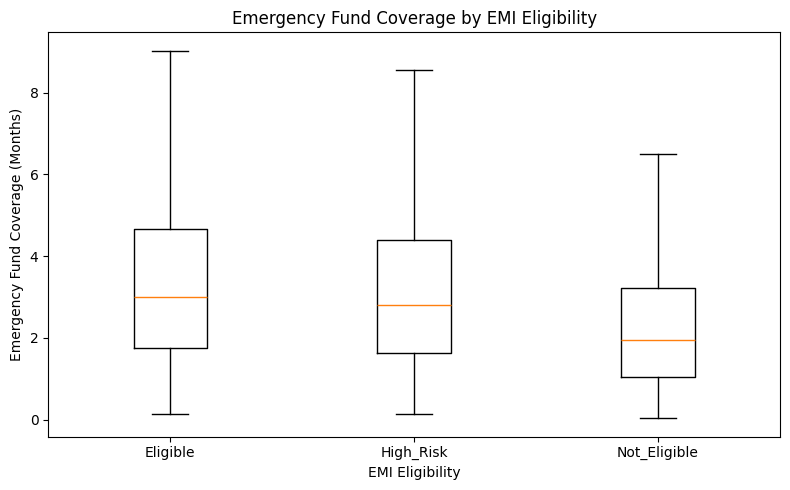

In [17]:
# Emergency-fund coverage analysis by EMI eligibility

emergency_coverage_summary = (
    df_features
    .groupby(TARGET_CLASSIFICATION)["emergency_fund_coverage"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

display(emergency_coverage_summary)


# Prepare groups for visualization
eligibility_order = [
    label
    for label in ["Eligible", "High_Risk", "Not_Eligible"]
    if label in df_features[TARGET_CLASSIFICATION].dropna().unique()
]

emergency_coverage_groups = [
    df_features.loc[
        df_features[TARGET_CLASSIFICATION] == label,
        "emergency_fund_coverage"
    ]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    for label in eligibility_order
]


# Box plot
plt.figure(figsize=(8, 5))

plt.boxplot(
    emergency_coverage_groups,
    tick_labels=eligibility_order,
    showfliers=False
)

plt.title("Emergency Fund Coverage by EMI Eligibility")
plt.xlabel("EMI Eligibility")
plt.ylabel("Emergency Fund Coverage (Months)")
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "emergency_fund_coverage_by_eligibility.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Business Insight — Emergency Fund Coverage

Emergency savings show a meaningful relationship with EMI eligibility.

- Eligible applicants have an average emergency-fund coverage of approximately **3.41 months** of expenses.
- High-risk applicants have approximately **3.22 months** of coverage.
- Not-eligible applicants have the lowest average coverage at approximately **2.36 months**.
- Median coverage falls from **2.99 months for Eligible** applicants to **1.95 months for Not_Eligible** applicants.

This suggests that applicants with stronger emergency savings generally have greater financial resilience and may be better positioned to manage additional EMI obligations.

However, the distributions overlap, so emergency-fund coverage should be considered together with income, expense burden, existing EMI obligations, credit score, and requested loan characteristics.

,count,mean,median,std
emi_eligibility,,,,
Eligible,74444,34078.57,28900.0,35605.76
High_Risk,17488,27571.92,22700.0,34673.62
Not_Eligible,312865,9579.73,6500.0,36555.56


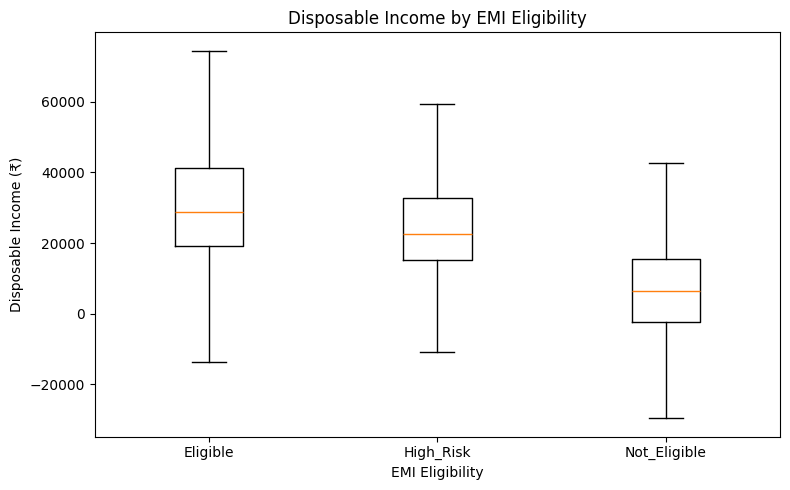

In [18]:
# Disposable income analysis by EMI eligibility

disposable_income_summary = (
    df_features
    .groupby(TARGET_CLASSIFICATION)["disposable_income"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

display(disposable_income_summary)


# Prepare groups for visualization
eligibility_order = [
    label
    for label in ["Eligible", "High_Risk", "Not_Eligible"]
    if label in df_features[TARGET_CLASSIFICATION].dropna().unique()
]

disposable_income_groups = [
    df_features.loc[
        df_features[TARGET_CLASSIFICATION] == label,
        "disposable_income"
    ]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    for label in eligibility_order
]


# Box plot
plt.figure(figsize=(8, 5))

plt.boxplot(
    disposable_income_groups,
    tick_labels=eligibility_order,
    showfliers=False
)

plt.title("Disposable Income by EMI Eligibility")
plt.xlabel("EMI Eligibility")
plt.ylabel("Disposable Income (₹)")
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "disposable_income_by_eligibility.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Business Insight — Disposable Income

Disposable income shows a strong relationship with EMI eligibility.

- Eligible applicants have the highest average disposable income at approximately **₹34,079 per month**.
- High-risk applicants average approximately **₹27,572 per month**.
- Not-eligible applicants have a much lower average disposable income of approximately **₹9,580 per month**.
- Median disposable income decreases sharply from **₹28,900 for Eligible** applicants to only **₹6,500 for Not_Eligible** applicants.
- Some applicants also have negative disposable income, indicating that their existing monthly expenses and EMI obligations already exceed their salary.

This suggests that remaining monthly financial capacity is an important indicator of whether a customer can safely take on an additional EMI.

However, disposable income should still be assessed together with credit score, existing debt, emergency savings, and requested loan characteristics.

,count,mean,median,std
emi_eligibility,,,,
Eligible,74444,0.188,0.133,0.257
High_Risk,17488,0.349,0.258,0.42
Not_Eligible,312865,0.876,0.54,1.036


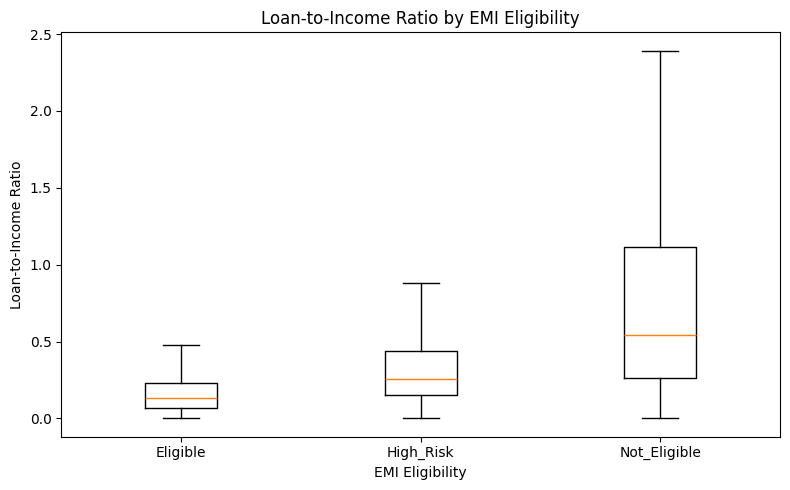

In [19]:
# Loan-to-income ratio analysis by EMI eligibility

loan_income_summary = (
    df_features
    .groupby(TARGET_CLASSIFICATION)["loan_to_income_ratio"]
    .agg(["count", "mean", "median", "std"])
    .round(3)
)

display(loan_income_summary)


# Prepare groups for visualization
eligibility_order = [
    label
    for label in ["Eligible", "High_Risk", "Not_Eligible"]
    if label in df_features[TARGET_CLASSIFICATION].dropna().unique()
]

loan_income_groups = [
    df_features.loc[
        df_features[TARGET_CLASSIFICATION] == label,
        "loan_to_income_ratio"
    ]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    for label in eligibility_order
]


# Box plot
plt.figure(figsize=(8, 5))

plt.boxplot(
    loan_income_groups,
    tick_labels=eligibility_order,
    showfliers=False
)

plt.title("Loan-to-Income Ratio by EMI Eligibility")
plt.xlabel("EMI Eligibility")
plt.ylabel("Loan-to-Income Ratio")
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "loan_to_income_ratio_by_eligibility.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Business Insight — Loan-to-Income Ratio

Loan-to-income ratio shows a strong relationship with EMI eligibility.

- Eligible applicants have an average loan-to-income ratio of approximately **18.8%**.
- High-risk applicants average approximately **34.9%**.
- Not-eligible applicants have a much higher average ratio of approximately **87.6%**.
- Median loan-to-income ratio increases from **13.3% for Eligible** applicants to **54.0% for Not_Eligible** applicants.

This indicates that applicants requesting larger loan amounts relative to their annual income tend to have lower EMI affordability.

The Not_Eligible group also shows much greater variation, suggesting that some applicants request amounts substantially above their income capacity.

Therefore, requested loan size should be evaluated relative to income rather than using the absolute requested amount alone.

,monthly_salary,total_monthly_expenses,disposable_income,expense_to_income_ratio,existing_emi_burden,credit_score,emergency_fund_coverage,loan_to_income_ratio,requested_amount,max_monthly_emi
monthly_salary,1.00,0.50,0.85,-0.26,-0.07,0.09,0.07,-0.30,-0.0,0.38
total_monthly_expenses,0.50,1.00,-0.01,0.18,0.01,0.11,-0.18,-0.25,0.0,0.11
disposable_income,0.85,-0.01,1.00,-0.39,-0.21,0.08,0.18,-0.19,-0.0,0.43
expense_to_income_ratio,-0.26,0.18,-0.39,1.00,0.31,-0.01,-0.23,0.32,0.0,-0.27
existing_emi_burden,-0.07,0.01,-0.21,0.31,1.00,-0.20,-0.00,0.11,0.0,-0.29
credit_score,0.09,0.11,0.08,-0.01,-0.20,1.00,0.01,-0.04,-0.0,0.30
emergency_fund_coverage,0.07,-0.18,0.18,-0.23,-0.00,0.01,1.00,-0.05,-0.0,0.36
loan_to_income_ratio,-0.30,-0.25,-0.19,0.32,0.11,-0.04,-0.05,1.00,0.7,-0.18
requested_amount,-0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00,0.70,1.0,-0.00
max_monthly_emi,0.38,0.11,0.43,-0.27,-0.29,0.30,0.36,-0.18,-0.0,1.00


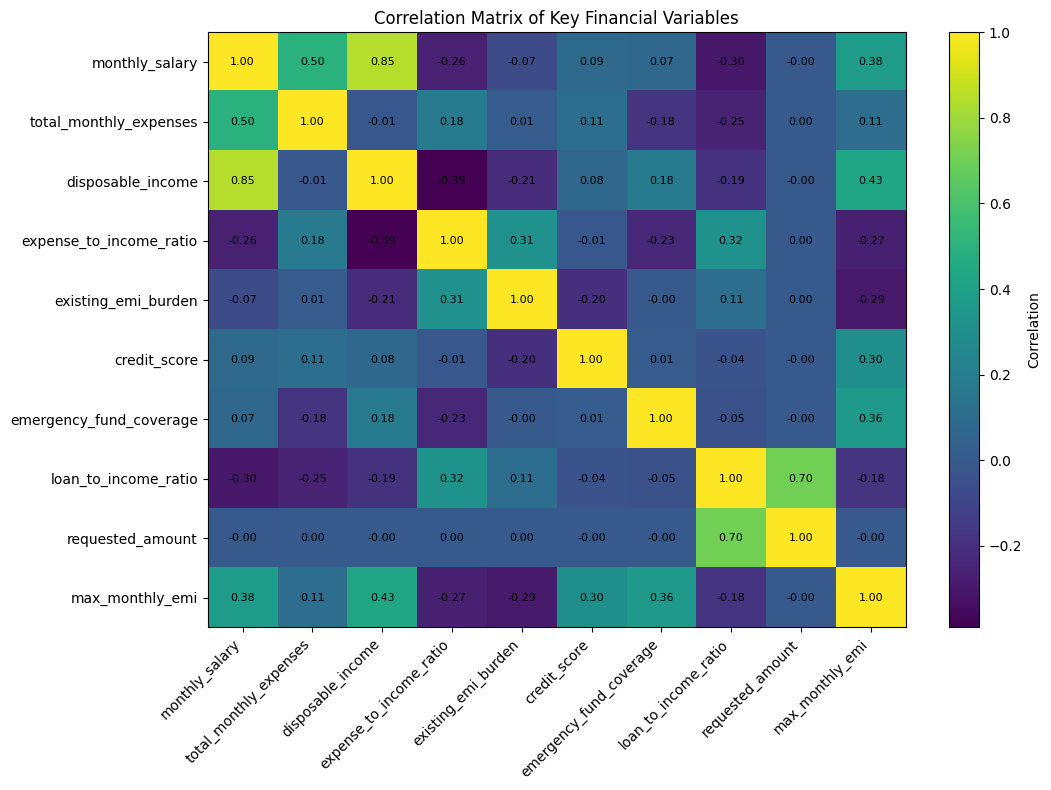

In [20]:
# Correlation analysis of key financial variables

correlation_columns = [
    "monthly_salary",
    "total_monthly_expenses",
    "disposable_income",
    "expense_to_income_ratio",
    "existing_emi_burden",
    "credit_score",
    "emergency_fund_coverage",
    "loan_to_income_ratio",
    "requested_amount",
    TARGET_REGRESSION,
]

correlation_matrix = (
    df_features[correlation_columns]
    .replace([np.inf, -np.inf], np.nan)
    .corr()
)

display(correlation_matrix.round(2))


# Correlation heatmap
plt.figure(figsize=(11, 8))

image = plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(image, label="Correlation")

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

# Add correlation values inside cells
for i in range(len(correlation_columns)):
    for j in range(len(correlation_columns)):
        value = correlation_matrix.iloc[i, j]

        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Correlation Matrix of Key Financial Variables")
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "financial_correlation_matrix.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Business Insight — Correlation Analysis

The correlation analysis highlights several important relationships with maximum safe EMI capacity.

- **Disposable income** has the strongest positive linear relationship with maximum EMI (**r = 0.43**), indicating that applicants with more income remaining after existing obligations can generally support larger EMI payments.
- **Monthly salary** is positively correlated with maximum EMI (**r = 0.38**).
- **Emergency-fund coverage** also shows a positive relationship (**r = 0.36**), suggesting that financial resilience contributes to affordability.
- **Credit score** has a moderate positive association with maximum EMI (**r = 0.30**).
- **Existing EMI burden** (**r = -0.29**) and **expense-to-income ratio** (**r = -0.27**) are negatively associated with EMI capacity.
- The raw **requested amount** has almost no linear relationship with maximum EMI, demonstrating why relative affordability measures such as loan-to-income ratio are more informative than absolute loan size alone.

Some engineered variables are mathematically related to their source variables. For example, disposable income is derived partly from monthly salary, and loan-to-income ratio contains requested amount. Therefore, these correlations should be interpreted as associations rather than independent causal relationships.

emi_eligibility,Eligible,High_Risk,Not_Eligible
employment_type,,,
Government,21.40,4.61,73.99
Private,17.80,4.27,77.94
Self-employed,16.52,4.09,79.39


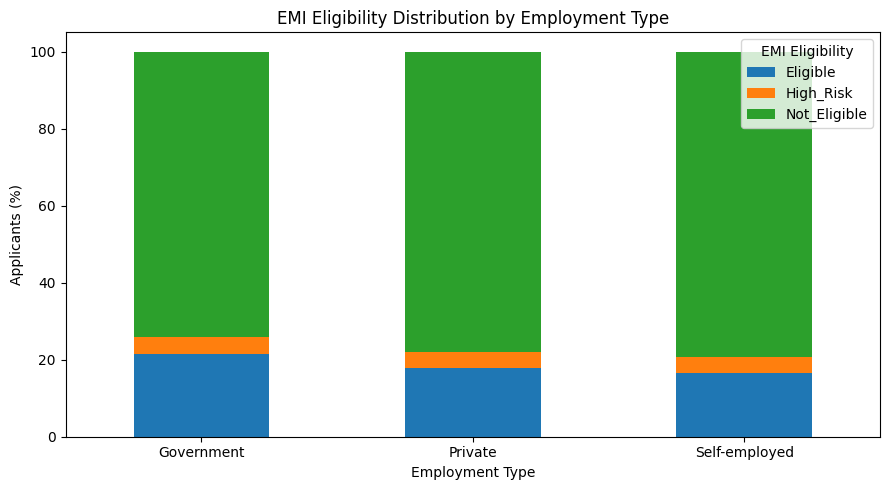

In [21]:
# Employment type vs EMI eligibility

employment_eligibility = pd.crosstab(
    df_features["employment_type"],
    df_features[TARGET_CLASSIFICATION],
    normalize="index"
) * 100

# Keep classes in a meaningful order
class_order = [
    label
    for label in ["Eligible", "High_Risk", "Not_Eligible"]
    if label in employment_eligibility.columns
]

employment_eligibility = (
    employment_eligibility[class_order]
    .round(2)
)

display(employment_eligibility)


# Stacked percentage bar chart
employment_eligibility.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("EMI Eligibility Distribution by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Applicants (%)")
plt.xticks(rotation=0)
plt.legend(title="EMI Eligibility")
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "eligibility_by_employment_type.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Business Insight — Employment Type

EMI eligibility varies moderately across employment categories.

- Government employees have the highest eligible share at approximately **21.4%**.
- Private-sector employees have an eligible share of approximately **17.8%**.
- Self-employed applicants have the lowest eligible share at approximately **16.5%**.
- The not-eligible share increases from approximately **74.0% for Government employees** to **79.4% for Self-employed applicants**.

This suggests that employment category may contribute some information about financial stability. However, the differences between groups are relatively moderate, so employment type should not be used as a standalone lending criterion.

Financial-capacity variables such as disposable income, expense burden, debt obligations, credit score, and loan-to-income ratio provide more direct measures of affordability.

,applicants,median_requested_amount,median_requested_tenure,median_max_monthly_emi,mean_disposable_income,Eligible_pct,High_Risk_pct,Not_Eligible_pct
emi_scenario,,,,,,,,
E-commerce Shopping EMI,80948,105000.0,14.0,4235.0,14910.46,26.32,4.95,68.74
Education EMI,80942,275000.0,27.0,4200.0,14880.48,17.73,4.76,77.50
Home Appliances EMI,80988,160000.0,21.0,4219.6,14961.61,26.00,5.19,68.81
Personal Loan EMI,80980,525000.0,36.0,4200.0,14781.41,11.34,3.42,85.25
Vehicle EMI,80942,792000.0,48.0,4200.0,14778.39,10.56,3.29,86.15


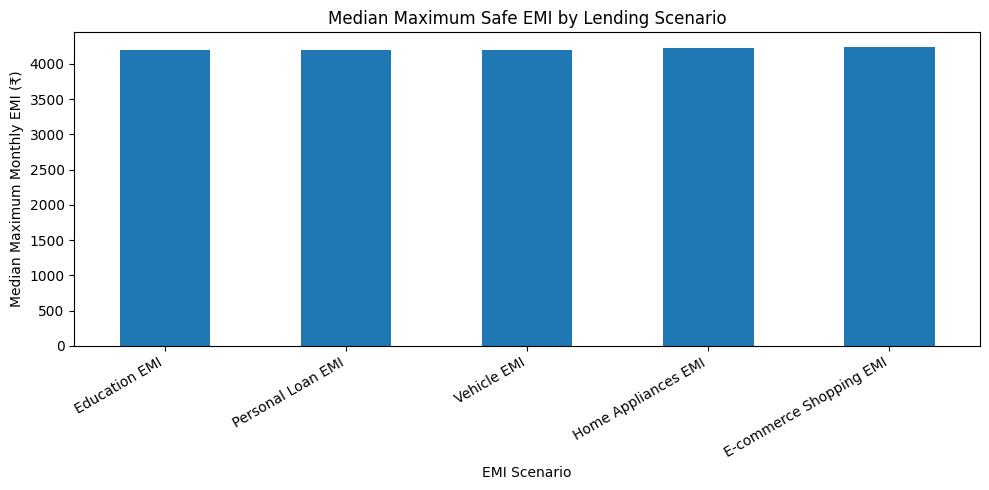

In [22]:
# Detailed EMI scenario analysis

# Percentage eligibility distribution within each scenario
scenario_eligibility_pct = (
    pd.crosstab(
        df_features["emi_scenario"],
        df_features[TARGET_CLASSIFICATION],
        normalize="index"
    ) * 100
).round(2)


# Financial profile of each EMI scenario
scenario_summary = (
    df_features
    .groupby("emi_scenario")
    .agg(
        applicants=("emi_scenario", "size"),
        median_requested_amount=("requested_amount", "median"),
        median_requested_tenure=("requested_tenure", "median"),
        median_max_monthly_emi=(TARGET_REGRESSION, "median"),
        mean_disposable_income=("disposable_income", "mean"),
    )
    .round(2)
)


# Add eligibility percentages
for class_name in ["Eligible", "High_Risk", "Not_Eligible"]:
    if class_name in scenario_eligibility_pct.columns:
        scenario_summary[f"{class_name}_pct"] = (
            scenario_eligibility_pct[class_name]
        )


display(scenario_summary)


# Visualize median safe EMI across scenarios
scenario_summary["median_max_monthly_emi"].sort_values().plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Median Maximum Safe EMI by Lending Scenario")
plt.xlabel("EMI Scenario")
plt.ylabel("Median Maximum Monthly EMI (₹)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "median_max_emi_by_scenario.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Business Insight — EMI Scenario Analysis

Eligibility varies substantially across different lending scenarios.

- E-commerce Shopping EMI has the highest eligible share at approximately **26.32%**, followed closely by Home Appliances EMI at **26.00%**.
- Education EMI has an eligible share of approximately **17.73%**.
- Personal Loan EMI falls to approximately **11.34%**.
- Vehicle EMI has the lowest eligible share at approximately **10.56%**, with **86.15%** of applicants classified as Not_Eligible.

The median requested amount increases significantly across these scenarios, from approximately **₹1.05 lakh for E-commerce EMI** to **₹7.92 lakh for Vehicle EMI**.

Interestingly, median maximum safe EMI capacity remains almost constant at approximately **₹4,200 per month** across all scenarios, while average disposable income is also similar.

This suggests that the differences in eligibility are associated more strongly with the size of the requested financial obligation relative to customer capacity than with major differences in underlying customer financial profiles.

Therefore, lending risk should be assessed using both customer affordability and scenario-specific requested loan characteristics.

## 7. Train, validation, and test split

The test set is isolated. We compare models on the validation set, choose the winners there, and report the selected models once on the untouched test set.


In [8]:
model_data = df_features.dropna(subset=[TARGET_CLASSIFICATION, TARGET_REGRESSION]).copy()

train_data, remaining_data = train_test_split(
    model_data,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=model_data[TARGET_CLASSIFICATION],
)
validation_data, test_data = train_test_split(
    remaining_data,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=remaining_data[TARGET_CLASSIFICATION],
)

if FAST_MODE and len(train_data) > TRAINING_SAMPLE_SIZE:
    train_data, _ = train_test_split(
        train_data,
        train_size=TRAINING_SAMPLE_SIZE,
        random_state=RANDOM_STATE,
        stratify=train_data[TARGET_CLASSIFICATION],
    )

X_train = train_data[feature_columns]
X_valid = validation_data[feature_columns]
X_test = test_data[feature_columns]

label_encoder = LabelEncoder()
y_train_class = label_encoder.fit_transform(train_data[TARGET_CLASSIFICATION])
y_valid_class = label_encoder.transform(validation_data[TARGET_CLASSIFICATION])
y_test_class = label_encoder.transform(test_data[TARGET_CLASSIFICATION])
y_train_reg = train_data[TARGET_REGRESSION]
y_valid_reg = validation_data[TARGET_REGRESSION]
y_test_reg = test_data[TARGET_REGRESSION]

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = [column for column in feature_columns if column not in numeric_features]

print(f"Train rows used: {len(X_train):,}")
print(f"Validation rows: {len(X_valid):,}")
print(f"Test rows: {len(X_test):,}")
print("Class labels:", list(label_encoder.classes_))


Train rows used: 100,000
Validation rows: 60,720
Test rows: 60,720
Class labels: ['Eligible', 'High_Risk', 'Not_Eligible']


## 8. Common preprocessing pipeline

A `ColumnTransformer` applies the same preprocessing to every model. It learns medians and categories from the training data only, which prevents train-test leakage.


In [9]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)


## 9. Helper functions for evaluation and MLflow

Macro F1 treats each eligibility class equally. RMSE gives more weight to large EMI prediction errors. The project uses validation metrics for selection, not the test set.


In [10]:
def classification_metrics(y_true, y_pred, y_probability) -> dict:
    # Calculate common multiclass classification metrics.
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }
    try:
        metrics["roc_auc_ovr"] = roc_auc_score(
            y_true, y_probability, multi_class="ovr", average="macro"
        )
    except ValueError:
        metrics["roc_auc_ovr"] = np.nan
    return metrics


def regression_metrics(y_true, y_pred) -> dict:
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": root_mean_squared_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
        "mape": mean_absolute_percentage_error(y_true, y_pred),
    }


MLFLOW_TRACKING_URI = f"sqlite:///{(PROJECT_ROOT / 'mlflow.db').as_posix()}"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
print(f"MLflow tracking URI: {MLFLOW_TRACKING_URI}")


MLflow tracking URI: sqlite:///C:/Users/jenis/OneDrive/Documents/ChatGPT/EMIPredict AI - Intelligent Financial Risk/mlflow.db


## 10. Classification models

We train three different approaches:

- Logistic Regression: simple, fast, and interpretable baseline.
- Random Forest: a tree ensemble that can learn non-linear patterns.
- XGBoost: gradient boosting for stronger non-linear performance.


In [11]:
tree_count = 80 if FAST_MODE else 180
classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
    "Random Forest Classifier": RandomForestClassifier(
        n_estimators=tree_count,
        max_depth=18,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "XGBoost Classifier": XGBClassifier(
        n_estimators=tree_count,
        max_depth=6,
        learning_rate=0.08,
        subsample=0.80,
        colsample_bytree=0.80,
        objective="multi:softprob",
        eval_metric="mlogloss",
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

mlflow.set_experiment("EMIPredict_Classification")
classification_rows = []
trained_classifiers = {}

for model_name, model in classification_models.items():
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    with mlflow.start_run(run_name=model_name):
        pipeline.fit(X_train, y_train_class)
        valid_prediction = pipeline.predict(X_valid)
        valid_probability = pipeline.predict_proba(X_valid)
        metrics = classification_metrics(y_valid_class, valid_prediction, valid_probability)

        mlflow.log_param("model_name", model_name)
        mlflow.log_param("fast_mode", FAST_MODE)
        mlflow.log_metrics({f"validation_{key}": float(value) for key, value in metrics.items() if pd.notna(value)})
        mlflow.sklearn.log_model(
    pipeline,
    name="model",
    serialization_format="skops",
    skops_trusted_types=[
        "numpy.dtype",
        "xgboost.core.Booster",
        "xgboost.sklearn.XGBClassifier",
    ],
)

    classification_rows.append({"model": model_name, **metrics})
    trained_classifiers[model_name] = pipeline
    print(f"Finished: {model_name}")

classification_results = pd.DataFrame(classification_rows).sort_values(
    "macro_f1", ascending=False
)
display(classification_results)


Finished: Logistic Regression
Finished: Random Forest Classifier
Finished: XGBoost Classifier


,model,accuracy,macro_f1,weighted_f1,precision_macro,recall_macro,roc_auc_ovr
2,XGBoost Classifier,0.963307,0.797782,0.956829,0.895709,0.765340,0.990580
1,Random Forest Classifier,0.942918,0.782444,0.944047,0.774740,0.790782,0.978882
0,Logistic Regression,0.912434,0.603252,0.893553,0.662462,0.617013,0.950843


## 11. Regression models

These models estimate the maximum safe monthly EMI. The model with the lowest validation RMSE is selected.


In [12]:
regression_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=tree_count,
        max_depth=18,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "XGBoost Regressor": XGBRegressor(
        n_estimators=tree_count,
        max_depth=6,
        learning_rate=0.08,
        subsample=0.80,
        colsample_bytree=0.80,
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

mlflow.set_experiment("EMIPredict_Regression")
regression_rows = []
trained_regressors = {}

for model_name, model in regression_models.items():
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    with mlflow.start_run(run_name=model_name):
        pipeline.fit(X_train, y_train_reg)
        valid_prediction = pipeline.predict(X_valid)
        metrics = regression_metrics(y_valid_reg, valid_prediction)

        mlflow.log_param("model_name", model_name)
        mlflow.log_param("fast_mode", FAST_MODE)
        mlflow.log_metrics({f"validation_{key}": float(value) for key, value in metrics.items()})
        mlflow.sklearn.log_model(
    pipeline,
    name="model",
    serialization_format="skops",
    skops_trusted_types=[
        "numpy.dtype",
        "xgboost.core.Booster",
        "xgboost.sklearn.XGBRegressor",
    ],
)

    regression_rows.append({"model": model_name, **metrics})
    trained_regressors[model_name] = pipeline
    print(f"Finished: {model_name}")

regression_results = pd.DataFrame(regression_rows).sort_values("rmse")
display(regression_results)


Finished: Linear Regression
Finished: Random Forest Regressor
Finished: XGBoost Regressor


,model,mae,rmse,r2,mape
2,XGBoost Regressor,312.318257,854.053253,0.987943,0.121246
1,Random Forest Regressor,239.509291,921.213839,0.985973,0.059823
0,Linear Regression,2899.795528,4063.094091,0.727123,1.876737


## 12. Best-model selection, untouched test metrics, and saved artifacts

The notebook chooses the best classification model by validation Macro F1 and the best regression model by validation RMSE. The final test metrics are reported only after this selection.


In [13]:
best_classification_name = classification_results.iloc[0]["model"]
best_regression_name = regression_results.iloc[0]["model"]
best_classifier = trained_classifiers[best_classification_name]
best_regressor = trained_regressors[best_regression_name]

classification_test_prediction = best_classifier.predict(X_test)
classification_test_probability = best_classifier.predict_proba(X_test)
classification_test_metrics = classification_metrics(
    y_test_class, classification_test_prediction, classification_test_probability
)

regression_test_prediction = best_regressor.predict(X_test)
regression_test_metrics = regression_metrics(y_test_reg, regression_test_prediction)

print("Best classification model:", best_classification_name)
print("Test metrics:", classification_test_metrics)
print("Best regression model:", best_regression_name)
print("Test metrics:", regression_test_metrics)

classification_results.to_csv(MODEL_DIR / "classification_comparison.csv", index=False)
regression_results.to_csv(MODEL_DIR / "regression_comparison.csv", index=False)
joblib.dump(best_classifier, MODEL_DIR / "best_classification_pipeline.joblib")
joblib.dump(best_regressor, MODEL_DIR / "best_regression_pipeline.joblib")

metadata = {
    "feature_columns": feature_columns,
    "class_labels": label_encoder.classes_.tolist(),
    "best_classification_model": best_classification_name,
    "best_regression_model": best_regression_name,
    "classification_test_metrics": classification_test_metrics,
    "regression_test_metrics": regression_test_metrics,
    "fast_mode": FAST_MODE,
}
(MODEL_DIR / "model_metadata.json").write_text(
    json.dumps(metadata, indent=2, default=float), encoding="utf-8"
)


Best classification model: XGBoost Classifier
Test metrics: {'accuracy': 0.9638339920948616, 'macro_f1': 0.8015362838421088, 'weighted_f1': 0.9574885404925424, 'precision_macro': 0.8991229067948886, 'recall_macro': 0.7683193098374402, 'roc_auc_ovr': 0.9905418354215577}
Best regression model: XGBoost Regressor
Test metrics: {'mae': 310.96456607966275, 'rmse': 851.1246672621113, 'r2': 0.9879188095954845, 'mape': 0.11873036785810161}


1492

## 12.1 Classification Error Analysis

,precision,recall,f1-score,support
Eligible,0.9241,0.9778,0.9502,11167.0000
High_Risk,0.7958,0.3313,0.4678,2623.0000
Not_Eligible,0.9775,0.9959,0.9866,46930.0000
accuracy,0.9638,0.9638,0.9638,0.9638
macro avg,0.8991,0.7683,0.8015,60720.0000
weighted avg,0.9598,0.9638,0.9575,60720.0000


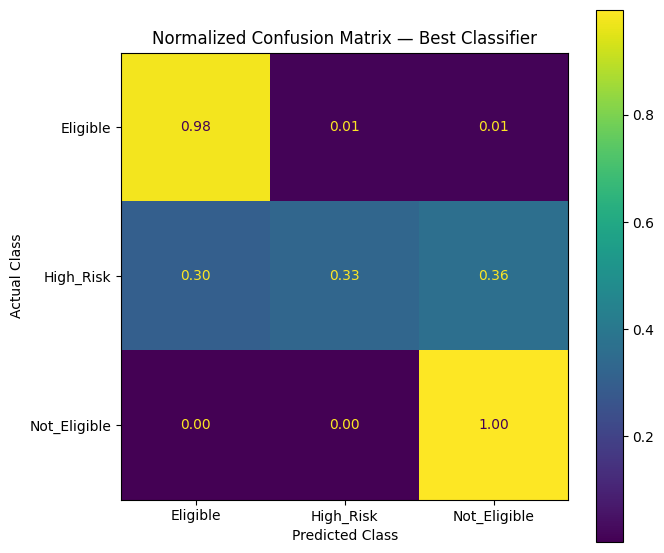

In [23]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)


# ---------------------------------------------------------
# 1. Per-class classification report
# ---------------------------------------------------------

classification_report_dict = classification_report(
    y_test_class,
    classification_test_prediction,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0,
)

classification_report_df = (
    pd.DataFrame(classification_report_dict)
    .T
    .round(4)
)

display(classification_report_df)


# ---------------------------------------------------------
# 2. Normalized confusion matrix
# ---------------------------------------------------------

normalized_cm = confusion_matrix(
    y_test_class,
    classification_test_prediction,
    normalize="true",
)

fig, ax = plt.subplots(figsize=(7, 6))

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=normalized_cm,
    display_labels=label_encoder.classes_,
)

display_cm.plot(
    ax=ax,
    values_format=".2f"
)

plt.title("Normalized Confusion Matrix — Best Classifier")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "classification_confusion_matrix.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Model Insight — Classification Error Analysis

The selected XGBoost classifier achieves strong overall test performance, but the per-class analysis reveals an important limitation.

- **Eligible** applicants achieve an F1-score of approximately **0.950**, with recall of **97.8%**.
- **Not_Eligible** applicants achieve an F1-score of approximately **0.987**, with recall of **99.6%**.
- **High_Risk** is the most difficult class, with an F1-score of approximately **0.468** and recall of only **33.1%**.
- Among actual High_Risk applicants, the model correctly identifies roughly one-third, while many are classified as either Eligible or Not_Eligible.

Although overall accuracy is approximately **96.38%**, the dataset is highly imbalanced, with substantially fewer High_Risk examples. Therefore, accuracy alone would overstate model quality.

For this reason, Macro F1 was used as the primary classification model-selection metric because it gives equal importance to each eligibility class.

In a production financial-risk system, improving High_Risk recall would be an important next step, potentially through class rebalancing, threshold tuning, additional features, or cost-sensitive learning.

## 12.2 Regression Error Analysis

Residual summary:


,Residual (₹)
count,60720.00
mean,-10.26
std,851.07
min,-34428.69
5%,-582.65
25%,-160.22
50%,-13.95
75%,105.84
95%,595.37
max,25905.35


Mean residual: ₹-10.26
Median residual: ₹-13.95


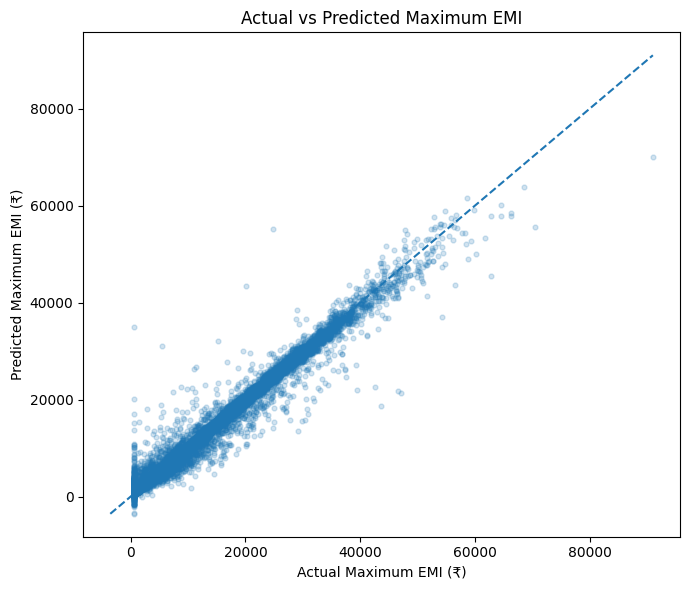

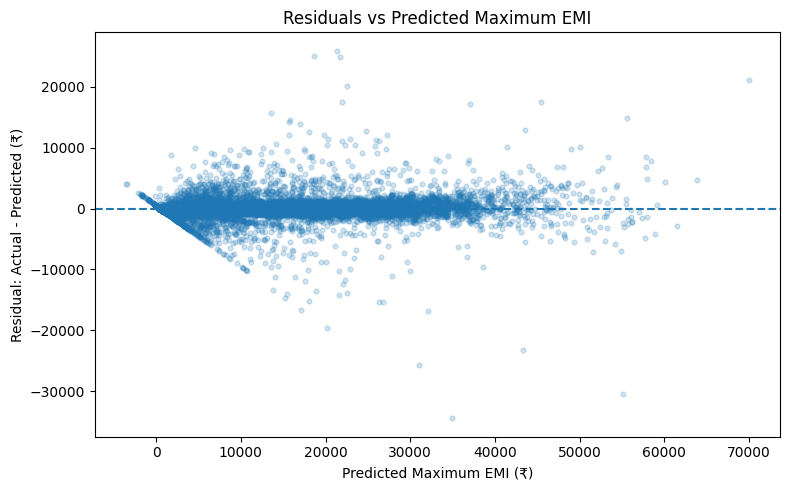

In [24]:
# ---------------------------------------------------------
# Regression residual analysis
# ---------------------------------------------------------

actual_emi = np.asarray(y_test_reg)
predicted_emi = np.asarray(regression_test_prediction)

# Residual = actual value - predicted value
residuals = actual_emi - predicted_emi

residual_summary = pd.Series(residuals).describe(
    percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
).round(2)

print("Residual summary:")
display(residual_summary.to_frame("Residual (₹)"))

print(f"Mean residual: ₹{residuals.mean():,.2f}")
print(f"Median residual: ₹{np.median(residuals):,.2f}")


# ---------------------------------------------------------
# 1. Actual vs Predicted EMI
# ---------------------------------------------------------

plt.figure(figsize=(7, 6))

plt.scatter(
    actual_emi,
    predicted_emi,
    alpha=0.20,
    s=12
)

minimum_value = min(actual_emi.min(), predicted_emi.min())
maximum_value = max(actual_emi.max(), predicted_emi.max())

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)

plt.title("Actual vs Predicted Maximum EMI")
plt.xlabel("Actual Maximum EMI (₹)")
plt.ylabel("Predicted Maximum EMI (₹)")
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "regression_actual_vs_predicted.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# 2. Residual Plot
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    predicted_emi,
    residuals,
    alpha=0.20,
    s=12
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residuals vs Predicted Maximum EMI")
plt.xlabel("Predicted Maximum EMI (₹)")
plt.ylabel("Residual: Actual - Predicted (₹)")
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "regression_residual_plot.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Model Insight — Regression Error Analysis

The selected XGBoost regressor demonstrates strong overall predictive performance.

- The mean residual is approximately **-₹10** and the median residual is approximately **-₹14**, indicating negligible systematic bias.
- Approximately 90% of residuals fall between about **-₹583 and +₹595**, showing that most predictions are close to the actual maximum EMI values.
- The Actual-vs-Predicted plot shows a strong concentration of observations around the ideal diagonal line, consistent with the test **R² of approximately 0.988**.
- The residual plot is generally centered around zero, suggesting no major global overprediction or underprediction pattern.
- Error dispersion becomes larger for some higher EMI predictions, indicating that prediction uncertainty is greater for uncommon or high-value financial profiles.
- A small number of extreme residuals remain, showing that edge cases can produce substantially larger prediction errors.

Therefore, the model performs strongly for typical applicants, while high-value and unusual financial profiles should receive additional monitoring or validation in a production financial-risk system.

## 12.3 Final Model Performance Comparison

CLASSIFICATION MODEL COMPARISON


,model,accuracy,macro_f1,weighted_f1,precision_macro,recall_macro,roc_auc_ovr
2,XGBoost Classifier,0.9633,0.7978,0.9568,0.8957,0.7653,0.9906
1,Random Forest Classifier,0.9429,0.7824,0.9440,0.7747,0.7908,0.9789
0,Logistic Regression,0.9124,0.6033,0.8936,0.6625,0.6170,0.9508



REGRESSION MODEL COMPARISON


,model,mae,rmse,r2,mape
2,XGBoost Regressor,312.3183,854.0533,0.9879,0.1212
1,Random Forest Regressor,239.5093,921.2138,0.9860,0.0598
0,Linear Regression,2899.7955,4063.0941,0.7271,1.8767


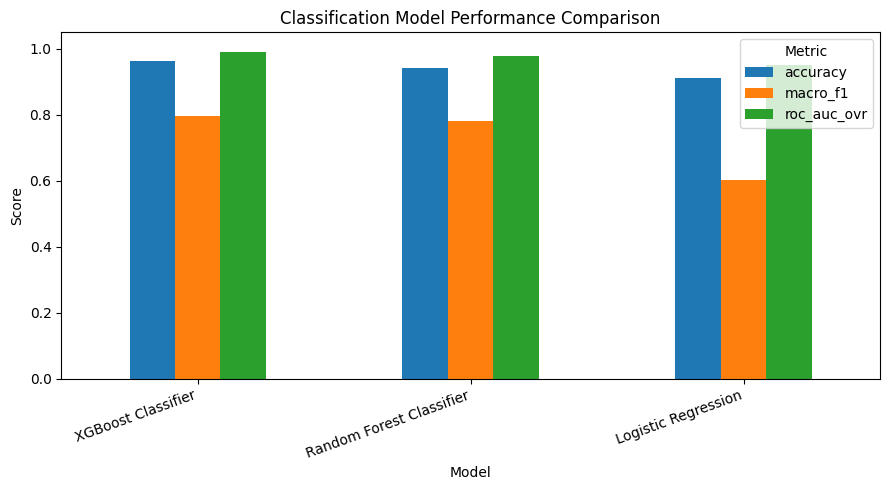

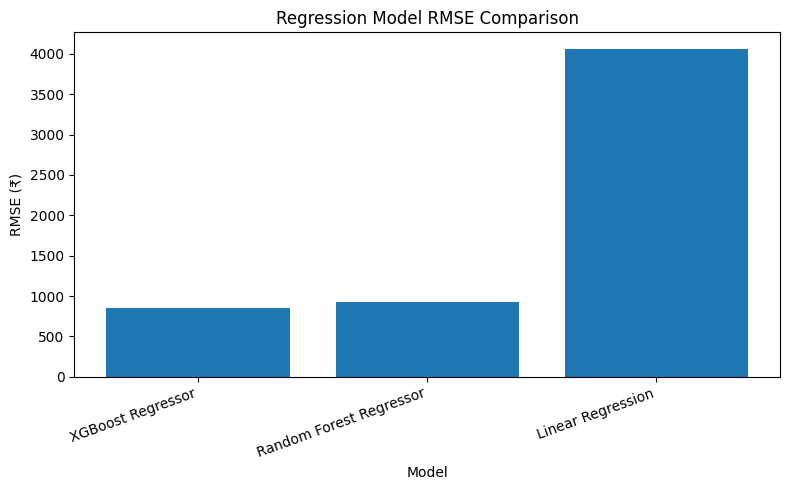

In [25]:
# ---------------------------------------------------------
# Final model performance comparison
# ---------------------------------------------------------

print("CLASSIFICATION MODEL COMPARISON")
display(
    classification_results[
        [
            "model",
            "accuracy",
            "macro_f1",
            "weighted_f1",
            "precision_macro",
            "recall_macro",
            "roc_auc_ovr",
        ]
    ].round(4)
)

print("\nREGRESSION MODEL COMPARISON")
display(
    regression_results[
        [
            "model",
            "mae",
            "rmse",
            "r2",
            "mape",
        ]
    ].round(4)
)


# ---------------------------------------------------------
# Classification comparison plot
# ---------------------------------------------------------

classification_plot = (
    classification_results
    .set_index("model")[["accuracy", "macro_f1", "roc_auc_ovr"]]
)

classification_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Classification Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Metric")
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "classification_model_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# Regression RMSE comparison
# ---------------------------------------------------------

regression_results_sorted = (
    regression_results
    .sort_values("rmse")
)

plt.figure(figsize=(8, 5))

plt.bar(
    regression_results_sorted["model"],
    regression_results_sorted["rmse"]
)

plt.title("Regression Model RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE (₹)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "regression_rmse_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Final Model Selection and Justification

#### Classification

Three classification models were evaluated: Logistic Regression, Random Forest, and XGBoost.

XGBoost was selected as the final classifier because it achieved the highest validation **Macro F1 of approximately 0.798**, together with the highest accuracy (**96.33%**) and ROC-AUC (**0.991**).

Macro F1 was prioritized because the eligibility classes are imbalanced and this metric gives equal importance to Eligible, High_Risk, and Not_Eligible applicants.

The final XGBoost classifier therefore provided the strongest overall balance across the three eligibility classes.

#### Regression

Three regression models were evaluated: Linear Regression, Random Forest, and XGBoost.

XGBoost was selected as the final regressor because it achieved the lowest validation **RMSE of approximately ₹854** and the highest **R² of approximately 0.988**.

RMSE was chosen as the primary regression-selection metric because large errors in maximum safe EMI estimation can be particularly important in a financial-risk application.

Random Forest achieved a lower MAE and MAPE, showing that it performs very well on typical prediction errors. However, XGBoost produced the lower RMSE, indicating better control of larger prediction errors.

Linear Regression performed substantially worse, suggesting that the relationship between customer financial characteristics and maximum EMI capacity is strongly non-linear.

## 13. Register the selected models with MLflow

This is a local model-registry attempt. If your environment does not support a local registry, the saved Joblib files still allow the Streamlit app to work.


In [14]:
SKOPS_TRUSTED_TYPES = [
    "numpy.dtype",
    "xgboost.core.Booster",
    "xgboost.sklearn.XGBClassifier",
    "xgboost.sklearn.XGBRegressor",
]


def log_and_register_selected_model(
    model,
    experiment_name,
    registered_name,
):
    mlflow.set_experiment(experiment_name)

    with mlflow.start_run(
        run_name=f"register_{registered_name}"
    ):

        model_info = mlflow.sklearn.log_model(
            model,
            name="best_model",
            serialization_format="skops",
            skops_trusted_types=SKOPS_TRUSTED_TYPES,
        )

        try:
            registered_model = mlflow.register_model(
                model_uri=model_info.model_uri,
                name=registered_name,
            )

            print(
                f"Registered model: "
                f"{registered_name}"
            )

        except Exception as error:
            print(
                f"Registry was not created: {error}"
            )


log_and_register_selected_model(
    best_classifier,
    "EMIPredict_Classification",
    "EMIPredict_Eligibility_Model",
)
log_and_register_selected_model(
    best_regressor,
    "EMIPredict_Regression",
    "EMIPredict_Max_EMI_Model",
)


Registered model 'EMIPredict_Eligibility_Model' already exists. Creating a new version of this model...
Created version '2' of model 'EMIPredict_Eligibility_Model'.


Registered model: EMIPredict_Eligibility_Model


Registered model 'EMIPredict_Max_EMI_Model' already exists. Creating a new version of this model...
Created version '2' of model 'EMIPredict_Max_EMI_Model'.


Registered model: EMIPredict_Max_EMI_Model


## 14. Business Impact and Recommendations

### 14.1 Business Impact Assessment

EMIPredict AI combines EMI eligibility classification and maximum safe EMI estimation into a single financial-risk assessment workflow.

The system can potentially support financial institutions in the following areas:

#### 1. Faster Initial Applicant Screening

The application automatically processes customer financial and demographic information and produces:

- EMI eligibility class: **Eligible, High_Risk, or Not_Eligible**
- Estimated maximum safe monthly EMI
- Eligibility probabilities
- Calculated affordability indicators
- Transparent recommendation notes

This can support an initial screening stage before detailed manual underwriting.

#### 2. More Consistent Affordability Assessment

Instead of evaluating applicants only through individual variables such as salary or credit score, the system combines multiple financial-capacity indicators including:

- Disposable income
- Expense-to-income ratio
- Existing EMI burden
- Credit score
- Emergency-fund coverage
- Loan-to-income ratio

This provides a more comprehensive affordability assessment.

#### 3. Maximum EMI Recommendation

The regression model estimates the maximum monthly EMI that an applicant may be able to support based on the financial profile.

The selected XGBoost regressor achieved:

- **RMSE ≈ ₹851**
- **MAE ≈ ₹311**
- **R² ≈ 0.988**

This enables the system to provide a data-driven EMI-capacity estimate rather than only a binary eligibility decision.

#### 4. Risk Segmentation

The classification model categorizes applicants into three groups:

- **Eligible**
- **High_Risk**
- **Not_Eligible**

This segmentation can help institutions differentiate straightforward cases from applications that may require additional review.

#### 5. Scenario-Specific Risk Assessment

The analysis showed substantial differences in eligibility across EMI scenarios.

- E-commerce Shopping EMI: approximately **26.3% Eligible**
- Home Appliances EMI: approximately **26.0% Eligible**
- Education EMI: approximately **17.7% Eligible**
- Personal Loan EMI: approximately **11.3% Eligible**
- Vehicle EMI: approximately **10.6% Eligible**

This indicates that requested financing characteristics should be considered together with customer financial capacity.

#### 6. Transparent Financial Indicators

The Streamlit application reports calculated financial measures such as disposable income, expense burden, existing EMI burden, emergency-fund coverage, and financial cushion.

These indicators make the prediction easier to review than presenting only a model label.

### Important Business Limitation

Although overall classification accuracy is approximately **96.4%**, the High_Risk class has recall of only approximately **33.1%**.

Therefore, the current model should not be used as an autonomous lending-decision system.

A more appropriate use would be as a **decision-support or preliminary screening tool**, with High_Risk and uncertain applications receiving additional human review.

### 14.2 Recommendations for Financial Institutions

- Use affordability ratios such as expense-to-income, loan-to-income, and disposable income instead of salary alone.
- Apply scenario-specific screening because eligibility differs across EMI categories.
- Use predicted maximum EMI as a supporting affordability estimate, not a final lending limit.
- Send High_Risk or uncertain cases for manual review because High_Risk recall is only about 33%.
- Monitor unusual/high-value applications because regression errors increase for some extreme cases.
- Use EMIPredict AI as a decision-support tool, not an automatic loan approval system.

## 15. Technical Architecture

EMIPredict AI follows an end-to-end machine-learning workflow:

Dataset (400K+ records)
↓
Data Cleaning
↓
Feature Engineering
↓
Train / Validation / Test Split
↓
Preprocessing Pipeline
↓
Classification + Regression Models
↓
Model Comparison
↓
Best Model Selection
↓
MLflow Tracking & Model Registry
↓
Joblib Model Saving
↓
Streamlit Application
↓
Cloud Deployment

### Main Components

- **Data Processing:** Cleans malformed values, missing data, and inconsistent categories.
- **Feature Engineering:** Creates financial indicators such as disposable income, expense-to-income ratio, EMI burden, and loan-to-income ratio.
- **Classification:** Predicts Eligible, High_Risk, or Not_Eligible.
- **Regression:** Predicts maximum safe monthly EMI.
- **MLflow:** Tracks experiments, metrics, and registered models.
- **Streamlit:** Provides real-time customer assessment and model information.
- **Deployment:** Application is deployed publicly using Streamlit Cloud.

## 16. Final notes for evaluation

- Start the MLflow interface with `mlflow ui` from the project folder.
- The saved files in `artifacts/models/` are used directly by `streamlit_app.py`.
- Explain that the test set was not used to choose models.
- Explain that financial ratios make the model inputs easier to discuss, but this application does not make actual lending decisions.
